Basic Data Processing...

In [30]:
import pandas as pd
sheets = pd.read_excel("./datasets/Scats Data October 2006.xls", sheet_name=None)

removed_days = sheets["Notes"]["Unnamed: 1"].dropna().to_list()[5:]
removed_days = [int(i) for i in removed_days]
# removed_days

df_info = sheets["Summary Of Data"].loc[2:]
df_info.columns = df_info.iloc[0]
df_info = df_info[1:]
df_info["SCATS Number"] = df_info["SCATS Number"].ffill()

df_info.dropna(axis=1, inplace=True)
df_info = df_info.convert_dtypes().infer_objects()
df_info.head(15)

df_info_filtered = df_info[df_info["Total"].between(7, 31)]
df_info_filtered

2,SCATS Number,Location,Total
3,0970,HIGH STREET_RD E of WARRIGAL_RD,31
4,0970,HIGH STREET_RD W of WARRIGAL_RD,30
5,0970,WARRIGAL_RD N of HIGH STREET_RD,31
6,0970,WARRIGAL_RD S of HIGH STREET_RD,31
7,2000,BURWOOD_HWY E of WARRIGAL_RD,29
...,...,...,...
137,4812,SWAN_ST SW of MADDEN_GV,26
138,4821,BURNLEY_ST S OF VICTORIA_ST,31
139,4821,VICTORIA_ST E OF BURNLEY_ST,31
140,4821,VICTORIA_ST W OF BURNLEY_ST,31


We create an identifier for each location: SCATS Number + HF Vicroads Internal

In [31]:

# imagine having good formatting
df = sheets["Data"]
df.columns = pd.Series(df.loc[0])
df = df.loc[1:]

# remove added time
df.loc[:, 'Date'] = pd.to_datetime(df['Date']).dt.date
df = df.convert_dtypes()

# filter good locations
df = df.loc[df["Location"].isin(df_info_filtered["Location"])]

# add location identifier: SCARS Number + VicRoads Internal
df.loc[:, "Identifier"] = df["SCATS Number"].astype(str) + " - " + df["HF VicRoads Internal"].astype(str)
df.columns = df.columns.str.strip()


df.head(10)


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V87,V88,V89,V90,V91,V92,V93,V94,V95,Identifier
1,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-01,...,97,97,66,81,50,59,47,29,34,0970 - 249
2,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-02,...,102,107,114,80,60,62,48,44,26,0970 - 249
3,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-03,...,132,114,86,93,90,73,57,29,40,0970 - 249
4,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-04,...,113,132,101,113,90,78,66,52,44,0970 - 249
5,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-05,...,120,116,113,99,91,61,55,49,36,0970 - 249
6,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-06,...,137,135,136,108,120,115,102,74,78,0970 - 249
7,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-07,...,153,133,109,140,121,123,115,107,127,0970 - 249
8,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-08,...,92,96,82,80,64,64,48,48,43,0970 - 249
9,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-09,...,107,111,98,83,69,57,50,25,36,0970 - 249
10,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-10,...,131,124,111,112,103,66,50,49,36,0970 - 249


In [51]:
df

,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V87,V88,V89,V90,V91,V92,V93,V94,V95,Identifier
1,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-01,...,97,97,66,81,50,59,47,29,34,0970 - 249
2,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-02,...,102,107,114,80,60,62,48,44,26,0970 - 249
3,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-03,...,132,114,86,93,90,73,57,29,40,0970 - 249
4,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-04,...,113,132,101,113,90,78,66,52,44,0970 - 249
5,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-05,...,120,116,113,99,91,61,55,49,36,0970 - 249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4188,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-27,...,121,127,103,122,124,117,99,108,88,4821 - 6673
4189,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-28,...,93,93,105,105,112,82,97,106,107,4821 - 6673
4190,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-29,...,118,83,76,66,64,77,60,49,45,4821 - 6673
4191,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-30,...,88,89,80,74,48,67,62,50,62,4821 - 6673


Format: Identifier + columns as timestamps

In [32]:
times_dict = {}
vcols = [f"V{str(i).zfill(2)}" for i in range(96)]
numbered_colnames = list(range(96 * 31))
for col in vcols:
    i = int(col[1:]) if len(col[1:]) > 0 else 0
    t = i * 15 
    h = t // 60 
    m = t % 60
    times_dict[col] = f"{str(h).zfill(2)}:{str(m).zfill(2)}" 
times_dict

{'V00': '00:00',
 'V01': '00:15',
 'V02': '00:30',
 'V03': '00:45',
 'V04': '01:00',
 'V05': '01:15',
 'V06': '01:30',
 'V07': '01:45',
 'V08': '02:00',
 'V09': '02:15',
 'V10': '02:30',
 'V11': '02:45',
 'V12': '03:00',
 'V13': '03:15',
 'V14': '03:30',
 'V15': '03:45',
 'V16': '04:00',
 'V17': '04:15',
 'V18': '04:30',
 'V19': '04:45',
 'V20': '05:00',
 'V21': '05:15',
 'V22': '05:30',
 'V23': '05:45',
 'V24': '06:00',
 'V25': '06:15',
 'V26': '06:30',
 'V27': '06:45',
 'V28': '07:00',
 'V29': '07:15',
 'V30': '07:30',
 'V31': '07:45',
 'V32': '08:00',
 'V33': '08:15',
 'V34': '08:30',
 'V35': '08:45',
 'V36': '09:00',
 'V37': '09:15',
 'V38': '09:30',
 'V39': '09:45',
 'V40': '10:00',
 'V41': '10:15',
 'V42': '10:30',
 'V43': '10:45',
 'V44': '11:00',
 'V45': '11:15',
 'V46': '11:30',
 'V47': '11:45',
 'V48': '12:00',
 'V49': '12:15',
 'V50': '12:30',
 'V51': '12:45',
 'V52': '13:00',
 'V53': '13:15',
 'V54': '13:30',
 'V55': '13:45',
 'V56': '14:00',
 'V57': '14:15',
 'V58': '14:30

In [33]:
import numpy as np
groups = df.groupby(by="Identifier")
df_processed = pd.DataFrame()

# add latitude and longtitude
lat_dict = {}
long_dict = {}
identifiers = []
locations_dict = {}

for id, group in groups:
    # all latitude and longtitude is the same
    lat_dict[id] = group["NB_LATITUDE"].iloc[0]
    long_dict[id] = group["NB_LONGITUDE"].iloc[0]
    locations_dict[id] = group["Location"].iloc[0].upper()
    
    combined = pd.concat([group[c] for c in vcols], ignore_index=True)
    df_processed[id] = combined
    
    # index
    identifiers.append(id)
    

    
# df_processed.fillna(-1, inplace=True)
df_processed = pd.concat([
    df_processed, pd.DataFrame([lat_dict]), pd.DataFrame([long_dict]), pd.DataFrame([locations_dict])
])

# post processing: row = identifier + lat-long for coordinate + flow

df_processed = df_processed.T.copy()
df_processed.columns = [*df_processed.columns[:-3], "lat", "long", "location"]
df_processed["id"] = [str(i).strip() for i in identifiers]
df_processed = df_processed[df_processed["lat"] != 0]

valid_lengths = df_processed[numbered_colnames].notna().sum(axis=1)
min_valid_len = valid_lengths.min()
print("Shortest complete length:", min_valid_len)

df_trimmed = df_processed.drop(labels=[i for i in numbered_colnames if i > min_valid_len], axis=1)
df_trimmed





Shortest complete length: 2112


,0,1,2,3,4,5,6,7,8,9,...,2107,2108,2109,2110,2111,2112,lat,long,location,id
0970 - 10503,92,31,20,32,42,31,87,108,32,29,...,423,361,365,414,380,422,-37.8676,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503
0970 - 16116,37,10,8,6,10,9,27,40,9,8,...,138,124,173,176,170,148,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116
0970 - 249,86,32,26,32,40,36,62,116,23,27,...,354,265,277,358,308,348,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249
0970 - 5887,47,15,10,20,16,42,67,23,16,22,...,351,349,383,318,352,214,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887
2000 - 10505,110,28,23,30,40,38,72,116,32,35,...,211,252,283,290,287,202,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4812 - 6302,49,16,15,22,14,28,38,47,11,8,...,44,56,46,60,73,67,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302
4821 - -1,0,1,0,3,2,2,0,0,0,0,...,11,9,12,17,5,9,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1
4821 - 14527,25,10,7,12,14,11,38,27,9,11,...,153,94,186,162,180,180,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527
4821 - 16911,44,14,14,25,23,20,46,55,13,21,...,167,187,152,180,195,212,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911


check missing data here

In [34]:
import numpy as np
import pandas as pd

missing_per_sensor = df_processed[numbered_colnames].isna().sum(axis=1)
missing_per_time = df_processed[numbered_colnames].isna().sum(axis=0)

print("Missing per sensor (rows):", missing_per_sensor.describe())
print("Missing per time step (columns):", missing_per_time.describe())


Missing per sensor (rows): count    136.000000
mean      84.000000
std      181.560642
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      864.000000
dtype: float64
Missing per time step (columns): count    2976.000000
mean        3.838710
std         8.448969
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        33.000000
dtype: float64


In [35]:
from matplotlib import pyplot as plt 

def count_trailing_nans(row):
    """Count consecutive NaNs from the end of a row (right side)."""
    # Convert to boolean array: True where NaN
    is_na = row.isna().to_numpy()
    
    # Reverse it, count consecutive True from start
    count = 0
    for val in is_na[::-1]:
        if val:
            count += 1
        else:
            break
    return count

a = df_processed[numbered_colnames].apply(count_trailing_nans, axis=1)
print(f"Max: {a.max()}")
print(f"Min: {a.min()}")


Max: 864
Min: 0


In [36]:
import numpy as np
import pandas as pd

numbered_colnames = list(range(96 * 31))
# df_processed[numbered_colnames].astype(float, copy=False)
missing_per_sensor = df_processed[numbered_colnames].isna().sum(axis=1)
missing_per_time = df_processed[numbered_colnames].isna().sum(axis=0)

print("Missing per sensor (rows):", missing_per_sensor.describe())
print("Missing per time step (columns):", missing_per_time.describe())


Missing per sensor (rows): count    136.000000
mean      84.000000
std      181.560642
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      864.000000
dtype: float64
Missing per time step (columns): count    2976.000000
mean        3.838710
std         8.448969
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        33.000000
dtype: float64


In [37]:
df_processed.columns

Index([         0,          1,          2,          3,          4,          5,
                6,          7,          8,          9,
       ...
             2970,       2971,       2972,       2973,       2974,       2975,
            'lat',     'long', 'location',       'id'],
      dtype='object', length=2980)

In [38]:
import numpy as np

def count_trailing_nans(row):
    return np.argmax(~np.isnan(row[::-1])) if np.isnan(row).any() else 0

trailing_nans = df_processed[numbered_colnames].copy(deep=True).fillna(np.nan)

trailing_nans


/tmp/ipykernel_12857/3176870093.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trailing_nans = df_processed[numbered_colnames].copy(deep=True).fillna(np.nan)


,0,1,2,3,4,5,6,7,8,9,...,2966,2967,2968,2969,2970,2971,2972,2973,2974,2975
0970 - 10503,92,31,20,32,42,31,87,108,32,29,...,39.0,33.0,38.0,58.0,55.0,86.0,119.0,45.0,37.0,66.0
0970 - 16116,37,10,8,6,10,9,27,40,9,8,...,7.0,11.0,11.0,11.0,22.0,32.0,33.0,12.0,15.0,14.0
0970 - 249,86,32,26,32,40,36,62,116,23,27,...,28.0,37.0,36.0,32.0,48.0,80.0,98.0,48.0,27.0,33.0
0970 - 5887,47,15,10,20,16,42,67,23,16,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000 - 10505,110,28,23,30,40,38,72,116,32,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4812 - 6302,49,16,15,22,14,28,38,47,11,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4821 - -1,0,1,0,3,2,2,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4821 - 14527,25,10,7,12,14,11,38,27,9,11,...,14.0,13.0,32.0,15.0,27.0,42.0,43.0,9.0,12.0,14.0
4821 - 16911,44,14,14,25,23,20,46,55,13,21,...,29.0,19.0,45.0,38.0,36.0,65.0,82.0,28.0,28.0,28.0


In [39]:
from matplotlib import pyplot as plt 
import numpy as np

numbered_colnames = [i for i in range(2976)]

def plot_identifier_flow(identifier: str):
    identifier = identifier.strip()
    row = df_processed[df_processed["id"] == identifier]
    data = row[numbered_colnames].to_numpy().flatten()
    print(data)
    
    
    plt.figure(figsize=(12, 4))
    
    plt.title(f"Observed data over sensor with identifier {identifier}")
    plt.xlabel("i'th 15-minute interval")
    plt.ylabel("Number of vehicles")
    plt.plot(np.arange(len(data)), data, "o", label=identifier)
    plt.legend()


# plot_identifier_flow("2000 - 10505")

We visualize the location using specific columns from our database

In [40]:
import numpy as np

df_locations = df_processed[["lat", "long", "location", "id"]].copy()

df_locations[["position", "road"]] = df_locations["location"].str.split(" OF ", n=1, expand=True)
df_locations["position"] = df_locations["position"].str.strip()
df_locations["road"] = df_locations["road"].str.strip()

df_locations = df_locations[df_locations["lat"] != 0]
df_locations.infer_objects()
df_locations

,lat,long,location,id,position,road
0970 - 10503,-37.8676,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503,WARRIGAL_RD S,HIGH STREET_RD
0970 - 16116,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116,HIGH STREET_RD E,WARRIGAL_RD
0970 - 249,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249,WARRIGAL_RD N,HIGH STREET_RD
0970 - 5887,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887,HIGH STREET_RD W,WARRIGAL_RD
2000 - 10505,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505,WARRIGAL_RD S,BURWOOD_HWY
...,...,...,...,...,...,...
4812 - 6302,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302,SWAN_ST NE,MADDEN_GV
4821 - -1,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1,WALMER_ST N,VICTORIA_ST
4821 - 14527,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527,BURNLEY_ST S,VICTORIA_ST
4821 - 16911,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911,VICTORIA_ST E,BURNLEY_ST


which allows us to draw this nice looking diagram

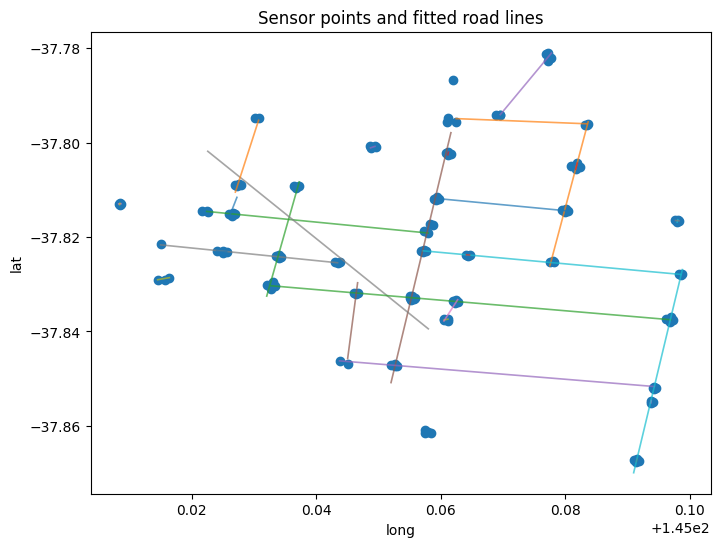

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(8, 6))

# scatter all points first
plt.scatter(df_locations["long"], df_locations["lat"])

for road, group in df_locations.groupby("road"):
    # drop any missing or zero coordinates
    g = group[(group["lat"] != 0) & (group["long"] != 0)]
    if len(g) < 2:
        continue

    # fit line latitude = a * longitude + b
    X = np.array(g["long"].values).reshape(-1, 1)
    y = np.array(g["lat"].values)
    model = LinearRegression().fit(X, y)
    x_line = np.linspace(X.min(), X.max(), 50)
    y_line = model.predict(x_line.reshape(-1, 1))

    # draw road line
    plt.figure
    plt.plot(x_line, y_line, lw=1.2, alpha=0.7, label=road)

plt.xlabel("long")
plt.ylabel("lat")
plt.title("Sensor points and fitted road lines")
# plt.legend()
plt.show()


Further location analysis...

for splitting

In [42]:
df_locations["position"] = df_locations["position"].astype(str).apply(lambda x: x.replace("HIGH STREET", "HIGH_STREET"))

df_locations

,lat,long,location,id,position,road
0970 - 10503,-37.8676,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503,WARRIGAL_RD S,HIGH STREET_RD
0970 - 16116,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116,HIGH_STREET_RD E,WARRIGAL_RD
0970 - 249,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249,WARRIGAL_RD N,HIGH STREET_RD
0970 - 5887,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887,HIGH_STREET_RD W,WARRIGAL_RD
2000 - 10505,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505,WARRIGAL_RD S,BURWOOD_HWY
...,...,...,...,...,...,...
4812 - 6302,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302,SWAN_ST NE,MADDEN_GV
4821 - -1,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1,WALMER_ST N,VICTORIA_ST
4821 - 14527,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527,BURNLEY_ST S,VICTORIA_ST
4821 - 16911,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911,VICTORIA_ST E,BURNLEY_ST


In [43]:
# df_locations["position"] = df_locations["position"].astype(str).apply(lambda x: x.replace("HIGH STREET", "HIGH_STREET"))
# df_locations["position"] = df_locations["position"].astype(str).apply(lambda x: x.replace("MONT ALBERT", "MONT_ALBERT"))

df_locations

,lat,long,location,id,position,road
0970 - 10503,-37.8676,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503,WARRIGAL_RD S,HIGH STREET_RD
0970 - 16116,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116,HIGH_STREET_RD E,WARRIGAL_RD
0970 - 249,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249,WARRIGAL_RD N,HIGH STREET_RD
0970 - 5887,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887,HIGH_STREET_RD W,WARRIGAL_RD
2000 - 10505,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505,WARRIGAL_RD S,BURWOOD_HWY
...,...,...,...,...,...,...
4812 - 6302,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302,SWAN_ST NE,MADDEN_GV
4821 - -1,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1,WALMER_ST N,VICTORIA_ST
4821 - 14527,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527,BURNLEY_ST S,VICTORIA_ST
4821 - 16911,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911,VICTORIA_ST E,BURNLEY_ST


In [44]:
a = df_locations["position"].str.split(" ").apply(lambda x: x[:-1][0]).to_list()
len(a)

136

In [57]:
df_locations["to"], df_locations["direction"] = a = df_locations["position"].str.split(" ").apply(lambda x: x[:-1][0]).to_list(), df_locations["position"].str.split(" ").apply(lambda x: x[-1][0]).to_list()
df_locations["to"] = df_locations["to"].astype(str).replace(" ", "_")
df_locations

,lat,long,location,id,position,road,to,direction
0970 - 10503,-37.8676,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503,WARRIGAL_RD S,HIGH STREET_RD,WARRIGAL_RD,S
0970 - 16116,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116,HIGH_STREET_RD E,WARRIGAL_RD,HIGH_STREET_RD,E
0970 - 249,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249,WARRIGAL_RD N,HIGH STREET_RD,WARRIGAL_RD,N
0970 - 5887,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887,HIGH_STREET_RD W,WARRIGAL_RD,HIGH_STREET_RD,W
2000 - 10505,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505,WARRIGAL_RD S,BURWOOD_HWY,WARRIGAL_RD,S
...,...,...,...,...,...,...,...,...
4812 - 6302,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302,SWAN_ST NE,MADDEN_GV,SWAN_ST,N
4821 - -1,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1,WALMER_ST N,VICTORIA_ST,WALMER_ST,N
4821 - 14527,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527,BURNLEY_ST S,VICTORIA_ST,BURNLEY_ST,S
4821 - 16911,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911,VICTORIA_ST E,BURNLEY_ST,VICTORIA_ST,E


Now for actual functionality. 

My teacher said that she wants an "adjacency graph". However, for the life of me, I can't find anything like that. However, we can determine something *approximately* approximately like that via our friend k-Nearest Neighbors!

In [58]:
from sklearn.metrics import pairwise_distances

coordinates = df_locations[["lat", "long"]].to_numpy().astype(np.float64)
print(pairwise_distances(coordinates, metric="haversine"))


[[0.         0.00054393 0.00058423 ... 0.09859992 0.09853288 0.09880458]
 [0.00054393 0.         0.00047788 ... 0.09886853 0.09880017 0.09907292]
 [0.00058423 0.00047788 0.         ... 0.09839673 0.09832816 0.09860108]
 ...
 [0.09859992 0.09886853 0.09839673 ... 0.         0.00028219 0.00021201]
 [0.09853288 0.09880017 0.09832816 ... 0.00028219 0.         0.00034903]
 [0.09880458 0.09907292 0.09860108 ... 0.00021201 0.00034903 0.        ]]


k-Nearest Neighbots

In [93]:
import numpy as np
from sklearn.metrics import pairwise_distances

# assuming df_locations is your DataFrame with NB_LATITUDE & NB_LONGITUDE and same order as the columns of your wide matrix
coords = df_locations[['lat','long']].to_numpy(dtype=float)

dist_rad = pairwise_distances(coords, metric='haversine')
earth_km = 6371.0
dist_km = dist_rad * earth_km

N = dist_km.shape[0]


k = 5
A = np.zeros((N,N))

for i in range(N):
    # exclude self
    neigh_idx = np.argsort(dist_km[i])[1:k+1]
    for j in neigh_idx:
        A[i, j] = 1
        A[j, i] = 1  # symmetric

# optional weighting
sigma = np.mean(dist_km[dist_km>0])
W = np.exp(-(dist_km**2)/(2*sigma**2))
A_weighted = W * (A>0)

# normalize each row
row_sum = A_weighted.sum(axis=1, keepdims=True)
A_norm = A_weighted / (row_sum + 1e-9)

# whatever matrix you choose (A, A_weighted, A_norm) becomes your adjacency
np.save("adjacency_matrix.npy", A_norm)

# also save mapping from index -> Identifier
np.save("node_identifiers.npy", df_locations['id'].to_numpy())


Big moment:

In [72]:
df_series = df_processed[numbered_colnames]

t = 10 ** 9

# check
for i in range(len(numbered_colnames)):
    if df_series[i].hasnans:
        df_series = df_series.drop(labels=[i], axis=1)
        
df_series = df_series.astype(np.float32)
df_series

,0,1,2,3,4,5,6,7,8,9,...,2102,2103,2104,2105,2106,2107,2108,2109,2110,2111
0970 - 10503,92.0,31.0,20.0,32.0,42.0,31.0,87.0,108.0,32.0,29.0,...,323.0,386.0,359.0,370.0,347.0,423.0,361.0,365.0,414.0,380.0
0970 - 16116,37.0,10.0,8.0,6.0,10.0,9.0,27.0,40.0,9.0,8.0,...,168.0,143.0,170.0,167.0,172.0,138.0,124.0,173.0,176.0,170.0
0970 - 249,86.0,32.0,26.0,32.0,40.0,36.0,62.0,116.0,23.0,27.0,...,328.0,352.0,271.0,266.0,302.0,354.0,265.0,277.0,358.0,308.0
0970 - 5887,47.0,15.0,10.0,20.0,16.0,42.0,67.0,23.0,16.0,22.0,...,365.0,367.0,363.0,186.0,107.0,351.0,349.0,383.0,318.0,352.0
2000 - 10505,110.0,28.0,23.0,30.0,40.0,38.0,72.0,116.0,32.0,35.0,...,296.0,277.0,324.0,321.0,260.0,211.0,252.0,283.0,290.0,287.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4812 - 6302,49.0,16.0,15.0,22.0,14.0,28.0,38.0,47.0,11.0,8.0,...,47.0,44.0,49.0,74.0,43.0,44.0,56.0,46.0,60.0,73.0
4821 - -1,0.0,1.0,0.0,3.0,2.0,2.0,0.0,0.0,0.0,0.0,...,4.0,8.0,1.0,2.0,8.0,11.0,9.0,12.0,17.0,5.0
4821 - 14527,25.0,10.0,7.0,12.0,14.0,11.0,38.0,27.0,9.0,11.0,...,148.0,152.0,115.0,106.0,148.0,153.0,94.0,186.0,162.0,180.0
4821 - 16911,44.0,14.0,14.0,25.0,23.0,20.0,46.0,55.0,13.0,21.0,...,200.0,188.0,239.0,224.0,175.0,167.0,187.0,152.0,180.0,195.0


In [99]:
arr = df_series.to_numpy().astype(np.float32)
arr

array([[ 92.,  31.,  20., ..., 365., 414., 380.],
       [ 37.,  10.,   8., ..., 173., 176., 170.],
       [ 86.,  32.,  26., ..., 277., 358., 308.],
       ...,
       [ 25.,  10.,   7., ..., 186., 162., 180.],
       [ 44.,  14.,  14., ..., 152., 180., 195.],
       [ 86.,  34.,  30., ..., 259., 266., 310.]],
      shape=(136, 2112), dtype=float32)

Training parameters

In [66]:
lag = 12
horizon = 1
batch_size = 64
epochs = 30

setup

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

arr = df_series.to_numpy().T.astype(np.float32)


N, T = arr.shape
print(N)
lag = 12  # or whatever you pick (12 timesteps = 3 hours if 15min each)
horizon = 1

lags = 12

X, y = [], []
for i in range(lags, data_scaled.shape[1]):
    X.append(data_scaled[:, i-lags:i].T)  # (lookback, 136)
    y.append(data_scaled[:, i])               # (136,)

X = np.array(X)    
y = np.array(y)
print(X.shape)
print(y.shape)

split_idx = int(0.8 * len(X))

X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]


from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(lags, N), return_sequences=False),
    Dense(N)
])
model.compile(optimizer="adamw", loss="mse")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2)




2112
(124, 12, 2112)
(124, 2112)
Epoch 1/50


/home/d/Documents/TrafficFlowPrediction/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 0.1261 - val_loss: 0.0834
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1123 - val_loss: 0.0706
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0972 - val_loss: 0.0566
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0805 - val_loss: 0.0436
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0642 - val_loss: 0.0343
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0519 - val_loss: 0.0293
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0439 - val_loss: 0.0268
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0391 - val_loss: 0.0251
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0352 - val_loss: 0.0240
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0332 - val_loss: 0.0233
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0319 - val_loss: 0.0225
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0313 - val_loss: 0.0219
Epoch 13/50

In [ ]:
import pandas as pd

# reverse the scaling
def inverse_scale(scaler, arr):
    return scaler.inverse_transform(arr.T).T

def predict_flow(identifier: str, start_idx: int, end_idx: int):
    """
    identifier: column name from df_series (e.g., '3002 - 10505')
    start_idx, end_idx: integer indices in the timeline
    """
    site_idx = df_series.columns.get_loc(identifier)
    
    preds = []
    for i in range(start_idx, end_idx):
        if i - lookback < 0: 
            continue
        x_input = data_spatial[:, i-lookback:i].T[np.newaxis, ...]  # shape (1, lookback, N)
        y_pred = model.predict(x_input, verbose=0)[0]
        preds.append(y_pred[site_idx])
    
    preds = np.array(preds)
    preds_inv = scaler.inverse_transform(preds.reshape(-1,1)).flatten()
    return preds_inv


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
(25, 2112)
[[ 52.334286  20.907593  17.183756 ... 192.96799  196.19724  205.83904 ]
 [ 56.094707  23.116426  19.245695 ... 198.51262  202.46617  204.83223 ]
 [ 59.709778  21.270443  19.354895 ... 199.08209  200.49734  195.31587 ]
 ...
 [ 55.916634  24.243513  23.667788 ... 174.74324  198.12619  169.13162 ]
 [ 56.36628   23.825228  19.942076 ... 200.61113  205.63496  204.65282 ]
 [ 52.771126  20.959656  17.42135  ... 195.04741  196.26723  205.4425  ]]
(25, 2112)
